# Task 3: Data Visualization — Tech Job Market
**CodeAlpha Data Analytics Internship**

Turning the EDA findings into clear, presentable visuals for the portfolio / LinkedIn video.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("india_job_market_2024_2026.csv")
df["skills_clean"] = df["Skills_Required"].fillna("").apply(
    lambda x: [s.strip().lower() for s in x.split(",") if s.strip()]
)
skills_exploded = df.explode("skills_clean")
skills_exploded = skills_exploded[skills_exploded["skills_clean"] != ""]


## 1. Postings count by role

/var/folders/28/hh_7d3ms1qgg6h9z2j51gkwm0000gn/T/ipykernel_19842/3774483400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.index, y=role_counts.values, palette="viridis")


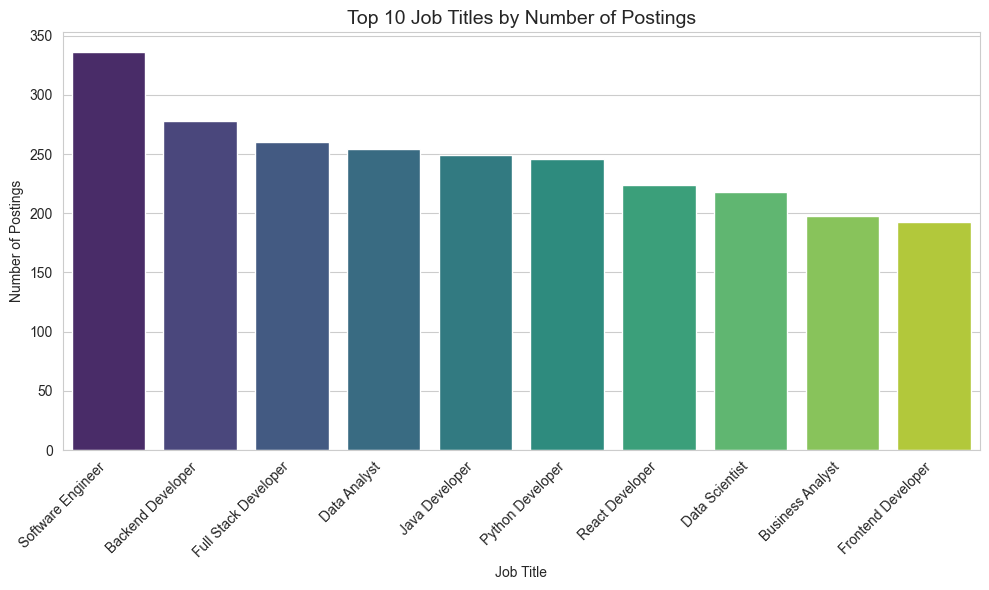

In [8]:
role_counts = df["Job_Title"].value_counts().head(10)

plt.figure()
sns.barplot(x=role_counts.index, y=role_counts.values, palette="viridis")
plt.title("Top 10 Job Titles by Number of Postings", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart1_postings_by_role.png", dpi=150)
plt.show()


## 2. Top 15 in-demand skills overall

/var/folders/28/hh_7d3ms1qgg6h9z2j51gkwm0000gn/T/ipykernel_19842/3917233171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette="mako")


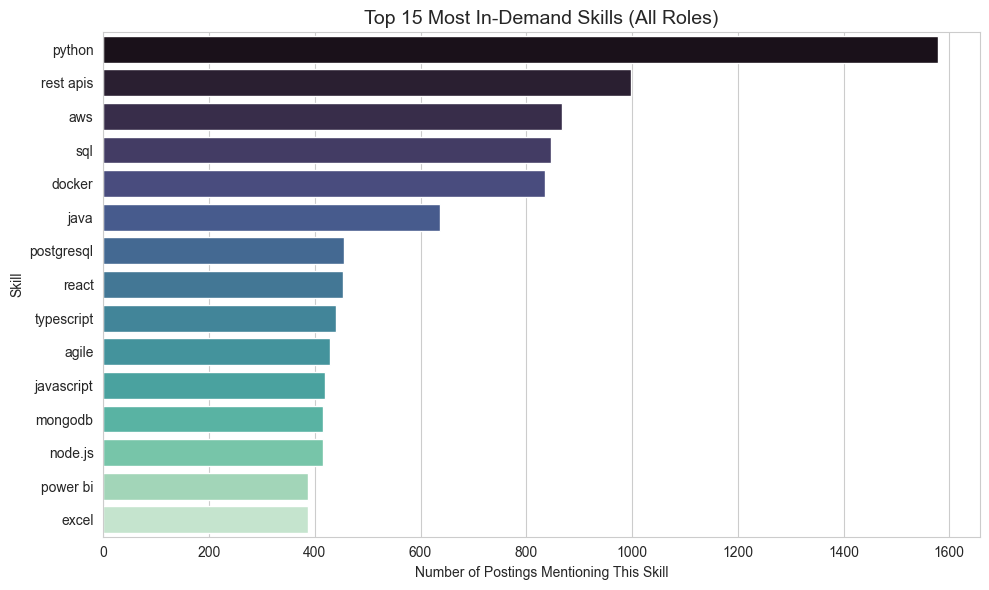

In [9]:
top_skills = skills_exploded["skills_clean"].value_counts().head(15)

plt.figure()
sns.barplot(x=top_skills.values, y=top_skills.index, palette="mako")
plt.title("Top 15 Most In-Demand Skills (All Roles)", fontsize=14)
plt.xlabel("Number of Postings Mentioning This Skill")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("chart2_top_skills_overall.png", dpi=150)
plt.show()


## 3. Skill comparison across roles (heatmap)
This is the standout chart — shows exactly how skill demand differs between your 3 roles.

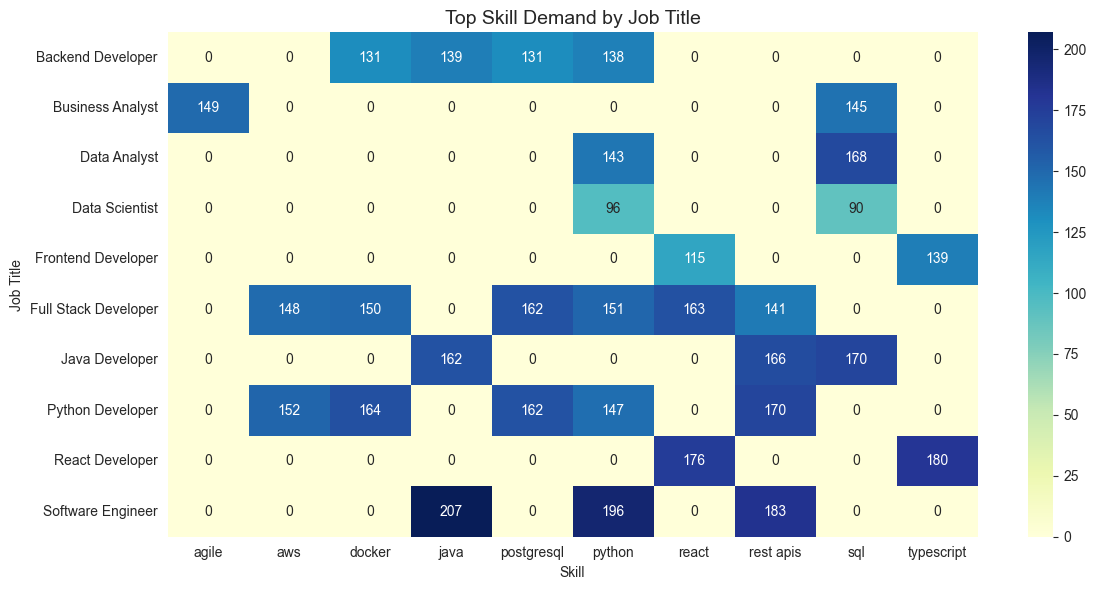

In [10]:
top_10_skills = skills_exploded["skills_clean"].value_counts().head(10).index
top_10_roles = df["Job_Title"].value_counts().head(10).index

pivot = (
    skills_exploded[
        skills_exploded["skills_clean"].isin(top_10_skills)
        & skills_exploded["Job_Title"].isin(top_10_roles)
    ]
    .groupby(["Job_Title", "skills_clean"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Top Skill Demand by Job Title", fontsize=14)
plt.xlabel("Skill")
plt.ylabel("Job Title")
plt.tight_layout()
plt.savefig("chart3_skills_heatmap.png", dpi=150)
plt.show()

## 4. Top hiring locations

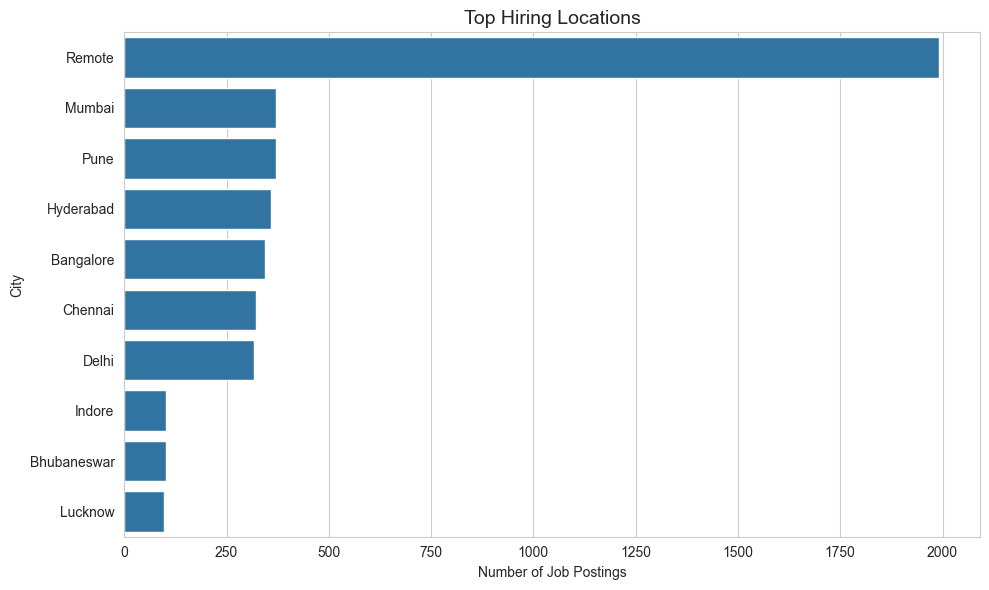

In [11]:
top_locations = df["City"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top Hiring Locations", fontsize=14)
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.tight_layout()

plt.savefig("chart_top_hiring_locations.png", dpi=150)
plt.show()

## 5. Experience level distribution

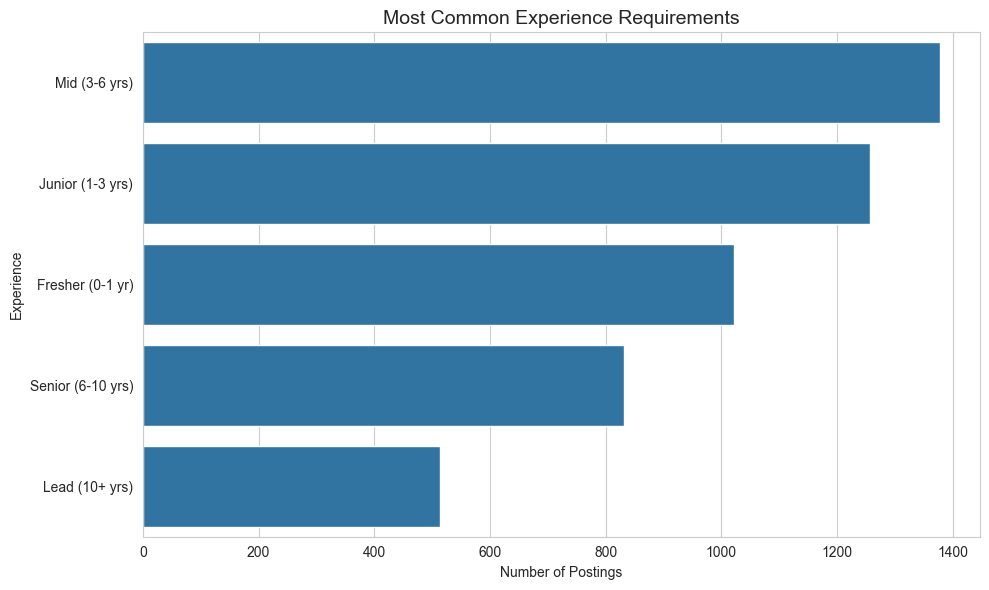

In [12]:
top_exp = df["Experience_Level"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_exp.values, y=top_exp.index)
plt.title("Most Common Experience Requirements", fontsize=14)
plt.xlabel("Number of Postings")
plt.ylabel("Experience")
plt.tight_layout()
plt.savefig("chart5_experience_levels.png", dpi=150)
plt.show()

## Portfolio note

All charts are saved as `.png` files in this folder — use these directly in your README and your
LinkedIn video screen-share. Pick 2-3 of the strongest ones (the heatmap is usually the most impressive)
to lead with.